
--- Clustered Data ---
   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1                  15                      39        2
1           2                  16                      81        0
2           3                  17                       6        1
3           4                  18                      77        0
4           5                  19                      40        2
5           6                  20                      76        0
6           7                  21                       6        1
7           8                  22                      94        0
8           9                  23                       3        1
9          10                  24                      72        0


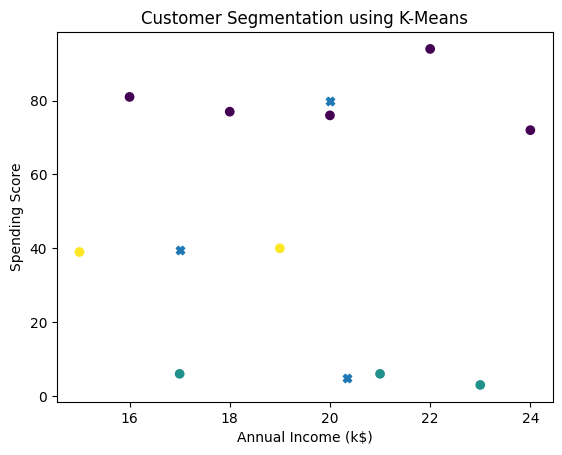

In [3]:
# Customer Segmentation using K-Means Clustering

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# -------------------------------
# 1. Create / Load Dataset
# -------------------------------
# You can replace this with: pd.read_csv("Mall_Customers.csv")
data = {
    "CustomerID": [1,2,3,4,5,6,7,8,9,10],
    "Annual Income (k$)": [15,16,17,18,19,20,21,22,23,24],
    "Spending Score (1-100)": [39,81,6,77,40,76,6,94,3,72]
}

df = pd.DataFrame(data)

# -------------------------------
# 2. Select Features for Clustering
# -------------------------------
# We use income and spending score to segment customers
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# -------------------------------
# 3. Apply K-Means Clustering
# -------------------------------
# n_clusters = 3 means we want to divide customers into 3 groups
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model and assign cluster labels
df["Cluster"] = kmeans.fit_predict(X)

# -------------------------------
# 4. Print Clustered Data
# -------------------------------
# Each customer now belongs to a cluster (0, 1, or 2)
print("\n--- Clustered Data ---")
print(df)

# -------------------------------
# 5. Visualize Clusters
# -------------------------------
# Scatter plot showing customer groups
plt.figure()
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=df["Cluster"])

# Plot cluster centroids (centers of groups)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()

# -------------------------------
# 6. Interpretation (for understanding)
# -------------------------------
# Cluster 0: Low income, low spending (budget customers)
# Cluster 1: Medium income, high spending (target customers)
# Cluster 2: High income, varied spending (premium customers)